# 26. 고장 해석 (Model Interpretation)

목적: 학습된 앙상블 모델에 대해 SHAP 기반의 다층적 해석을 수행합니다.

| 섹션 | 내용 |
| --- | --- |
| **§9.1 전역적 해석 (Global)** | SHAP Summary Plot — 전체 데이터 기준 주요 고장 기여 피처 분석 |
| **§9.2 국소적 해석 (Local)** | SHAP Waterfall Plot — 특정 개체(시리얼)의 고장 예측 근거 설명 |
| **§9.3 시간 기반 해석 (Temporal)** | 고장 전 N일 창에서의 SHAP 기여도 변화 trajectory 추적 |

> ⚠️ 사전 조건: `07_threshold_tuning.ipynb` 및 `08_final_evaluation.ipynb` 실행 완료 후 진행하세요.

## 0. 환경 준비

In [11]:
import sys, os, json, joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

sys.path.insert(0, os.path.abspath(".."))

%load_ext autoreload
%autoreload 2

import config.interp_config as cfg
import config.train_config as tcfg
import config.final_eval_config as fe_cfg
from src.eval_core import prepare_disk_level_data, get_detailed_disk_records

warnings.filterwarnings("ignore")

# 한글 폰트 설정
for _font in ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]:
    if any(_font.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = _font
        break
plt.rcParams["axes.unicode_minus"] = False

print("✅ 환경 준비 완료")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ 환경 준비 완료


## 1. 모델 및 데이터 로드

In [12]:
from pathlib import Path

SAVE_DIR = Path(tcfg.MODEL_SAVE_DIR)

# ── 피처 목록 로드 ─────────────────────────────────────────
with open(SAVE_DIR / "feature_cols.json", encoding="utf-8") as f:
    FEATURE_COLS = json.load(f)

# ── 앙상블 모델 로드 ───────────────────────────────────────
models = [joblib.load(p) for p in sorted(SAVE_DIR.glob("subset_*.pkl"))]

# ── 최적 임계값 로드 (final_eval_config 에서 가져옴) ─────────
# 수동 오버라이드 (config에 설정된 경우 우선 적용)
BEST_T = getattr(fe_cfg, "MANUAL_BEST_T", None)
BEST_N = getattr(fe_cfg, "MANUAL_BEST_N", None)
if BEST_T is None or BEST_N is None:
    with open(SAVE_DIR / "best_threshold.json", encoding="utf-8") as f:
        th_data = json.load(f)
        if BEST_T is None: BEST_T = th_data["threshold"]
        if BEST_N is None: BEST_N = th_data["min_alarms"]
ALARM_WINDOW = getattr(fe_cfg, "ALARM_WINDOW", 14)

# ── 테스트 데이터 로드 (고장 당일 포함본) ───────────────────
# interp_config 대신 최신 데이터가 반영된 final_eval_config의 경로 사용
test_path = Path(fe_cfg.TEST_PATH)
df_test = pd.read_parquet(test_path)
df_test[cfg.DATE_COL] = pd.to_datetime(df_test[cfg.DATE_COL])
df_test['base_serial'] = df_test[cfg.SERIAL_COL].str.replace(r'_\d+$', '', regex=True)

# ── 앙상블 예측 (캐시 활용) ─────────────────────────────────
cache_filename = f"{test_path.stem}_probs.npy"
cache_path = SAVE_DIR / cache_filename

if os.path.exists(cache_path):
    print(f"♻️ 캐시 로드 중: {cache_filename}")
    y_prob = np.load(cache_path)
    if len(y_prob) != len(df_test):
        print("⚠️ 데이터 크기 불일치. 재예측 수행...")
        y_prob = np.mean([m.predict_proba(df_test[FEATURE_COLS])[:, 1] for m in models], axis=0)
        np.save(cache_path, y_prob)
else:
    print(f"🔄 앙상블 추론 중... (모델 {len(models)}개 × 데이터 {len(df_test):,}행)")
    y_prob = np.mean([m.predict_proba(df_test[FEATURE_COLS])[:, 1] for m in models], axis=0)
    np.save(cache_path, y_prob)

df_test["_prob"]  = y_prob

print(f"✅ 로드 완료: 피처 {len(FEATURE_COLS)}개 | 운영점 T={BEST_T:.4f}, n={BEST_N} (W={ALARM_WINDOW})")
print(f"   테스트 데이터: {len(df_test):,}행 | 고장행: {df_test[cfg.TARGET_COL].sum():,}")

# ── 실제 디스크 단위 알람 이력 추출 (n회 연속 조건 반영) ──────
disks_data, n_fail, n_norm = prepare_disk_level_data(df_test, y_prob)
df_best_disk = get_detailed_disk_records(disks_data, BEST_T, BEST_N, window_size=ALARM_WINDOW)
# _alarm 컬럼을 단순 확률(1회)가 아니라 n회 조건 만족 여부로 생성하기 위해 
# 원래 df_test 에 매핑하기는 복잡하므로 df_best_disk 정보를 활용합니다.


♻️ 캐시 로드 중: test_with_failure_date_probs.npy
✅ 로드 완료: 피처 27개 | 운영점 T=0.9261, n=2 (W=14)
   테스트 데이터: 15,696,223행 | 고장행: 12,256


KeyboardInterrupt: 

---
## §9.1 전역적 해석 (Global Interpretability)

SHAP Summary Plot을 통해 전체 테스트 데이터에서 어떤 피처가 고장 예측에 얼마나, 어떤 방향으로 기여하는지 분석합니다.

- 앙상블 모델 전체의 평균 SHAP 값을 사용
- **x축:** 개별 예측에 대한 SHAP 값 (양수 = 고장 확률 증가에 기여)
- **색상:** 해당 피처의 원본 값 수준 (붉을수록 높은 값)

In [ ]:
import shap

# SHAP 계산용 5:5 균형 추출 (고장 패턴을 전역 해석에서 뚜렷하게 보기 위함)
sample_size = min(cfg.SHAP_SAMPLE_SIZE, len(df_test))
target_fail_count = sample_size // 2

# 1. 고장/정상 인덱스 분리
fail_indices = df_test[df_test[cfg.TARGET_COL] == 1].index
norm_indices = df_test[df_test[cfg.TARGET_COL] == 0].index

# 2. 고장 데이터 샘플링 (전체 샘플의 절반을 목표로 하되, 모자라면 전수 사용)
n_fail_sample = min(len(fail_indices), target_fail_count)
# 나머지를 정상 데이터로 채움
n_norm_sample = sample_size - n_fail_sample

fail_sample = df_test.loc[fail_indices].sample(n_fail_sample, random_state=cfg.SHAP_SEED)
norm_sample = df_test.loc[norm_indices].sample(n_norm_sample, random_state=cfg.SHAP_SEED)

# 3. 데이터셋 결합 및 셔플 (순서가 뭉치지 않게)
df_sample = pd.concat([fail_sample, norm_sample]).sample(frac=1, random_state=cfg.SHAP_SEED).reset_index(drop=True)

X_sample = df_sample[FEATURE_COLS]
y_sample = df_sample[cfg.TARGET_COL]

print(f"SHAP 계산 준비... (샘플={sample_size:,}, 모델={len(models)}개)")
print(f"  → 균형 튜닝 추출 완료: 고장 {n_fail_sample:,}개 / 정상 {n_norm_sample:,}개")

shap_cache_path = SAVE_DIR / f"shap_cache_seed{cfg.SHAP_SEED}_size{sample_size}.npy"

if os.path.exists(shap_cache_path):
    print(f"♻️ 전역 SHAP 캐시 로드 중: {shap_cache_path.name}")
    mean_shap = np.load(shap_cache_path)
    print(f"✅ SHAP 캐시 로드 완료!")
else:
    print("  ※ 모델 수 × 샘플 수에 비례하여 수 분 소요될 수 있습니다.")
    sv_list = []
    for i, model in enumerate(models):
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X_sample)
        if isinstance(sv, list):
            sv = sv[1]  # 이진 분류: 양성 클래스(고장) SHAP
        sv_list.append(sv)
        print(f"  모델 {i+1}/{len(models)} 완료", end="\r")
    
    mean_shap = np.mean(sv_list, axis=0)
    np.save(shap_cache_path, mean_shap)
    try:
        import subprocess
        subprocess.run(['git', 'add', str(shap_cache_path)], check=True)
        print(f'\n✅  SHAP 계산 및 캐시 저장(Git Add 자동화) 완료!')
    except Exception as e:
        print(f'\n✅  SHAP 계산 및 캐시 저장 완료! (Git 자동 등록 실패: {e})')


SHAP 계산 준비... (샘플=6,000, 모델=10개)
  → 균형 튜닝 추출 완료: 고장 3,000개 / 정상 3,000개
♻️ 전역 SHAP 캐시 로드 중: shap_cache_seed42_size6000.npy
✅ SHAP 캐시 로드 완료!


[§9.1] SHAP Summary Plot (전역 해석)


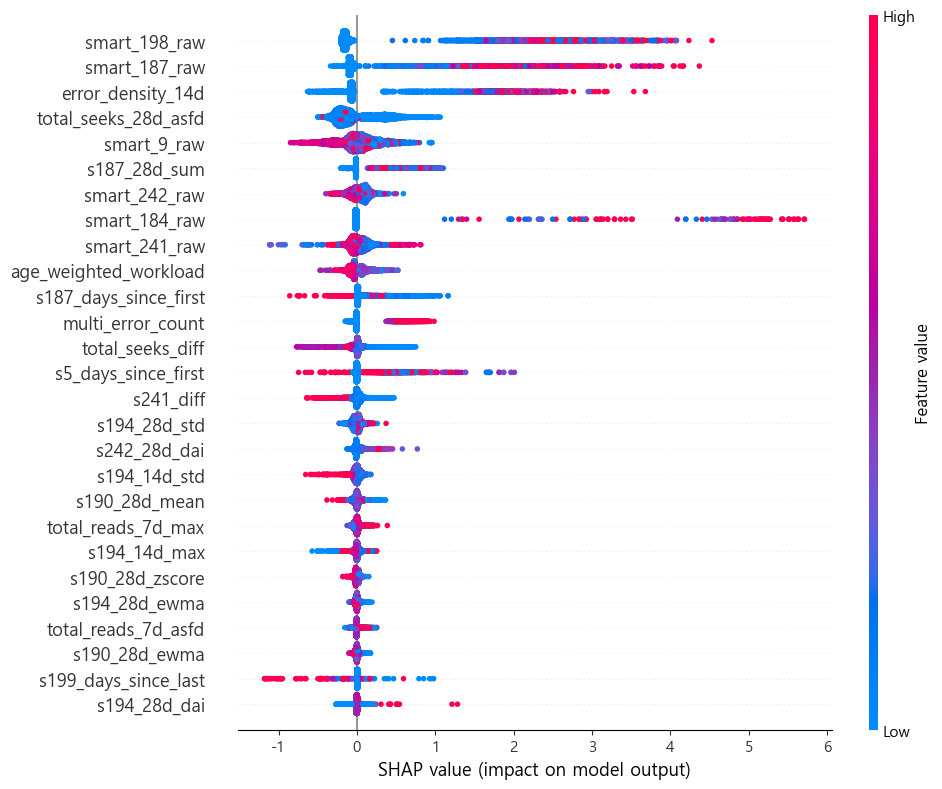

In [ ]:
# §9.1 Summary Plot (Beeswarm)
print("[§9.1] SHAP Summary Plot (전역 해석)")
shap.summary_plot(
    mean_shap,
    X_sample,
    feature_names=FEATURE_COLS,
    max_display=cfg.SHAP_MAX_DISPLAY,
    show=True,
    plot_size=(10, 8),
)

[§9.1] SHAP Bar Plot (Mean |SHAP| 기준 피처 중요도)


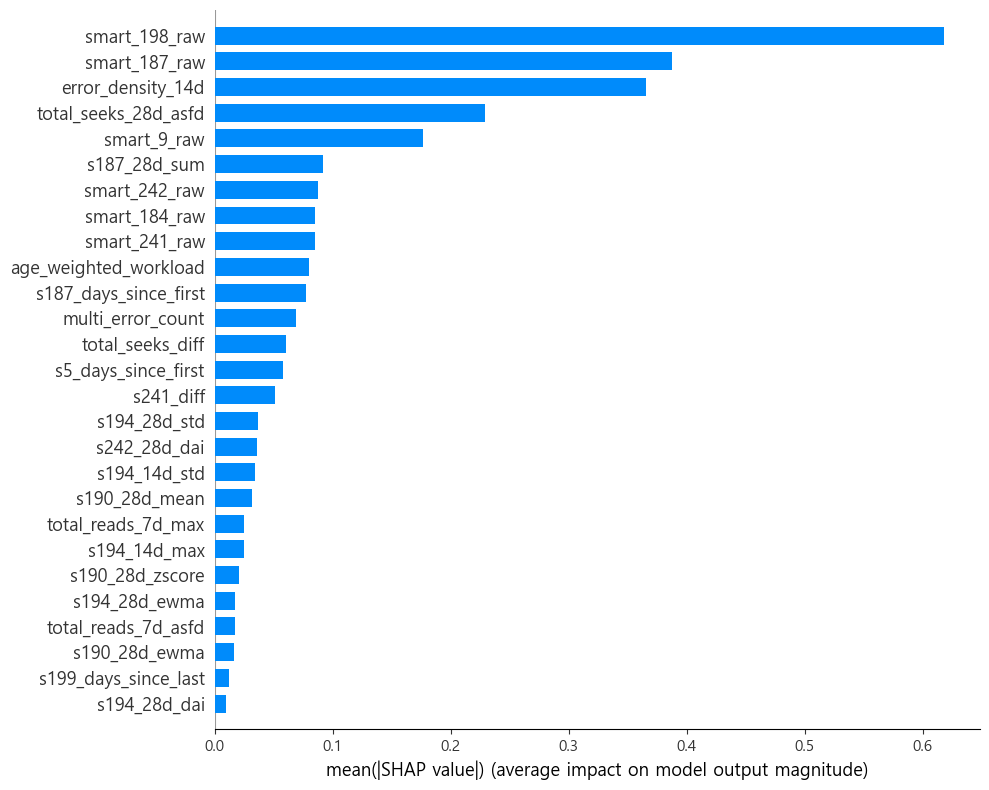


📊 피처 중요도 순위 (Mean |SHAP|):
|    | feature               |   mean_abs_shap |
|---:|:----------------------|----------------:|
|  1 | smart_198_raw         |      0.6176     |
|  2 | smart_187_raw         |      0.387535   |
|  3 | error_density_14d     |      0.36514    |
|  4 | total_seeks_28d_asfd  |      0.228769   |
|  5 | smart_9_raw           |      0.176668   |
|  6 | s187_28d_sum          |      0.0915711  |
|  7 | smart_242_raw         |      0.0875417  |
|  8 | smart_184_raw         |      0.0854291  |
|  9 | smart_241_raw         |      0.0849411  |
| 10 | age_weighted_workload |      0.0799305  |
| 11 | s187_days_since_first |      0.0776488  |
| 12 | multi_error_count     |      0.0692159  |
| 13 | total_seeks_diff      |      0.0605762  |
| 14 | s5_days_since_first   |      0.0577827  |
| 15 | s241_diff             |      0.0514774  |
| 16 | s194_28d_std          |      0.0371828  |
| 17 | s242_28d_dai          |      0.0356629  |
| 18 | s194_14d_std          |      0.034

In [ ]:
# §9.1 Bar Plot — 절댓값 평균 기준 피처 중요도
print("[§9.1] SHAP Bar Plot (Mean |SHAP| 기준 피처 중요도)")
shap.summary_plot(
    mean_shap,
    X_sample,
    feature_names=FEATURE_COLS,
    max_display=cfg.SHAP_MAX_DISPLAY,
    plot_type="bar",
    show=True,
    plot_size=(10, 8),
)

# 중요도 순위 테이블 출력
mean_abs_shap = np.abs(mean_shap).mean(axis=0)
shap_rank_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
shap_rank_df.index += 1
print("\n📊 피처 중요도 순위 (Mean |SHAP|):")
print(shap_rank_df.to_markdown())

---
## §9.2 국소적 해석 (Local Interpretability)

특정 개체(시리얼 번호)에 대해 SHAP Waterfall Plot을 통해 고장 예측의 근거를 설명합니다.

- 고장이 났으나 탐지하지 못한 **미탐 개체** 또는 **탐지 성공 개체**를 선택하여 분석
- 어떤 피처가 어느 방향으로 고장 확률을 끌어올리거나 낮췄는지 확인 가능

In [ ]:
# 분석 대상 시리얼 선택 (비교 분석을 위해 다중 타겟 지원)
target_serials = []
if cfg.TARGET_SERIAL is not None:
    target_serials.append(cfg.TARGET_SERIAL)
    print(f"[수동 지정] 분석 대상: {target_serials[0]}")
else:
    hit_disks = df_best_disk[(df_best_disk['is_failed'] == 1) & (df_best_disk['is_alarmed'] == 1)]
    miss_disks = df_best_disk[(df_best_disk['is_failed'] == 1) & (df_best_disk['is_alarmed'] == 0)]
    fa_disks = df_best_disk[(df_best_disk['is_failed'] == 0) & (df_best_disk['is_alarmed'] == 1)]
    
    selected_types = []
    if len(hit_disks) > 0:
        target_serials.append(hit_disks.sample(1, random_state=cfg.SHAP_SEED).iloc[0]['base_serial'])
        selected_types.append("Hit(탐지 성공)")
    if len(miss_disks) > 0:
        target_serials.append(miss_disks.sample(1, random_state=cfg.SHAP_SEED).iloc[0]['base_serial'])
        selected_types.append("Miss(미탐)")
        
    if len(fa_disks) > 0:
        # 🌟 단순 라벨상 오탐이 아니라, '알람 발령 후 30일 이상 멀쩡히 살아남은 진짜 오탐' 개체 필터링
        real_fa_serial = None
        for s in fa_disks.sample(frac=1, random_state=cfg.SHAP_SEED)['base_serial']:
            df_s = df_test[df_test['base_serial'] == s]
            alarms = (df_s['_prob'] >= BEST_T).astype(int)
            rolling = alarms.rolling(window=ALARM_WINDOW, min_periods=1).sum()
            idx = np.where(rolling >= BEST_N)[0]
            if len(idx) > 0:
                first_alarm = df_s[cfg.DATE_COL].iloc[idx[0]]
                last_obs = df_s[cfg.DATE_COL].max()
                if (last_obs - first_alarm).days >= 30:
                    real_fa_serial = s
                    break
                    
        if real_fa_serial is not None:
            target_serials.append(real_fa_serial)
            selected_types.append("FA(진짜 오탐)")
        else:
            target_serials.append(fa_disks.sample(1, random_state=cfg.SHAP_SEED).iloc[0]['base_serial'])
            selected_types.append("FA(오탐)")
        
    print(f"[자동 선택] 비교 분석을 위해 {', '.join(selected_types)} 개체를 각각 1개씩 추출했습니다.")

def print_lifecycle(serial_num, disk_info):
    df_entity = df_test[df_test['base_serial'] == serial_num].sort_values(cfg.DATE_COL)
    first_obs = df_entity[cfg.DATE_COL].min().date()
    last_obs = df_entity[cfg.DATE_COL].max().date()
    
    print(f"\n  [개체 생애 (Lifecycle) 요약: {serial_num}]")
    print(f"  - 데이터 수집 기간 : {first_obs} ~ {last_obs} (총 {len(df_entity)}일간 관측)")
    
    raw_alarms = df_entity[df_entity['_prob'] >= BEST_T]
    
    if disk_info['is_alarmed'] == 1:
        if disk_info['is_failed'] == 1:
            first_alarm = last_obs - pd.Timedelta(days=disk_info['lead_time']) if not np.isnan(disk_info['lead_time']) else "해당 없음"
            print(f"  - 시스템 최종 확정 : {first_alarm} (고장 {disk_info['lead_time']}일 전 감지)")
        else:
            alarms = (df_entity['_prob'] >= BEST_T).astype(int)
            rolling = alarms.rolling(window=ALARM_WINDOW, min_periods=1).sum()
            idx = np.where(rolling >= BEST_N)[0]
            first_alarm_date = df_entity[cfg.DATE_COL].iloc[idx[0]].date() if len(idx) > 0 else "N/A"
            days_before = (last_obs - first_alarm_date).days if len(idx) > 0 else "N/A"
            print(f"  - 시스템 최종 확정 : {first_alarm_date} (알람 발령 후 {days_before}일 동안 고장 없이 정상 동작함)")
    else:
        print(f"  - 시스템 최종 확정 : 없음 (경보 미발령)")
        
    if len(raw_alarms) > 0:
        alarm_details = []
        for d in raw_alarms[cfg.DATE_COL].dt.date.values:
            days_before = (last_obs - d).days
            alarm_details.append(f"D-{days_before}")
        print(f"  - 모델 단일 경고 이력: 총 {len(raw_alarms)}회 ({', '.join(alarm_details)})")
    else:
        print(f"  - 모델 단일 경고 이력: 없음")
        
    if disk_info['is_failed'] == 1:
        status = '✅ 탐지 성공 (Hit)' if disk_info['is_alarmed'] else '❌ 미탐 (Miss)'
        fail_text = '고장'
    else:
        status = '❌ 오탐 (False Alarm)' if disk_info['is_alarmed'] else '✅ 정상 정탐 (True Negative)'
        fail_text = '정상'
        
    print(f"  - 최종 평가 결과   : {status} ({fail_text} 디스크)\n")

for serial in target_serials:
    info = df_best_disk[df_best_disk['base_serial'] == serial].iloc[0]
    print("="*60)
    print_lifecycle(serial, info)


[자동 선택] 비교 분석을 위해 Hit(탐지 성공), Miss(미탐), FA(진짜 오탐) 개체를 각각 1개씩 추출했습니다.

  [개체 생애 (Lifecycle) 요약: S301KX66]
  - 데이터 수집 기간 : 2015-11-05 ~ 2020-07-07 (총 1678일간 관측)
  - 시스템 최종 확정 : 2020-07-04 (고장 3.0일 전 감지)
  - 모델 단일 경고 이력: 총 5회 (D-4, D-3, D-2, D-1, D-0)
  - 최종 평가 결과   : ✅ 탐지 성공 (Hit) (고장 디스크)


  [개체 생애 (Lifecycle) 요약: Z305DTQS]
  - 데이터 수집 기간 : 2016-02-09 ~ 2021-03-17 (총 1850일간 관측)
  - 시스템 최종 확정 : 없음 (경보 미발령)
  - 모델 단일 경고 이력: 총 1회 (D-0)
  - 최종 평가 결과   : ❌ 미탐 (Miss) (고장 디스크)


  [개체 생애 (Lifecycle) 요약: Z3015L9W]
  - 데이터 수집 기간 : 2014-04-01 ~ 2018-07-30 (총 1568일간 관측)
  - 시스템 최종 확정 : 2018-06-12 (알람 발령 후 48일 동안 고장 없이 정상 동작함)
  - 모델 단일 경고 이력: 총 3회 (D-49, D-48, D-44)
  - 최종 평가 결과   : ❌ 오탐 (False Alarm) (정상 디스크)




[§9.2] Waterfall Plot — 개체: S301KX66
       최고 위험 시점: 2020-07-07 (예측 확률=0.9423)


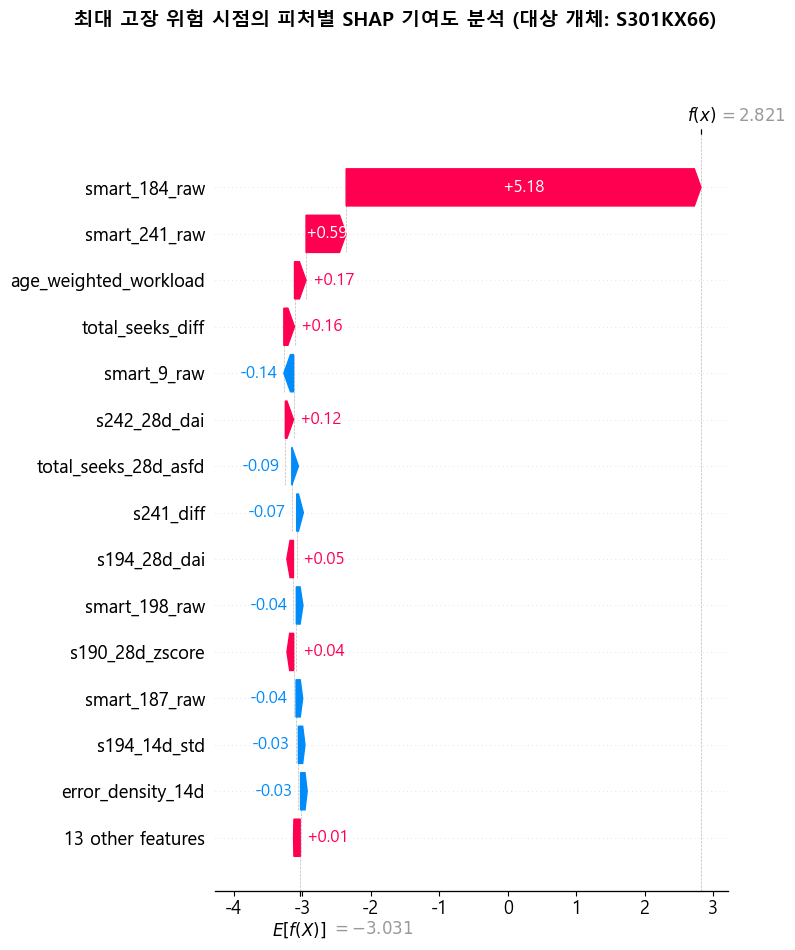


[§9.2] Waterfall Plot — 개체: Z305DTQS
       최고 위험 시점: 2021-03-17 (예측 확률=0.9445)


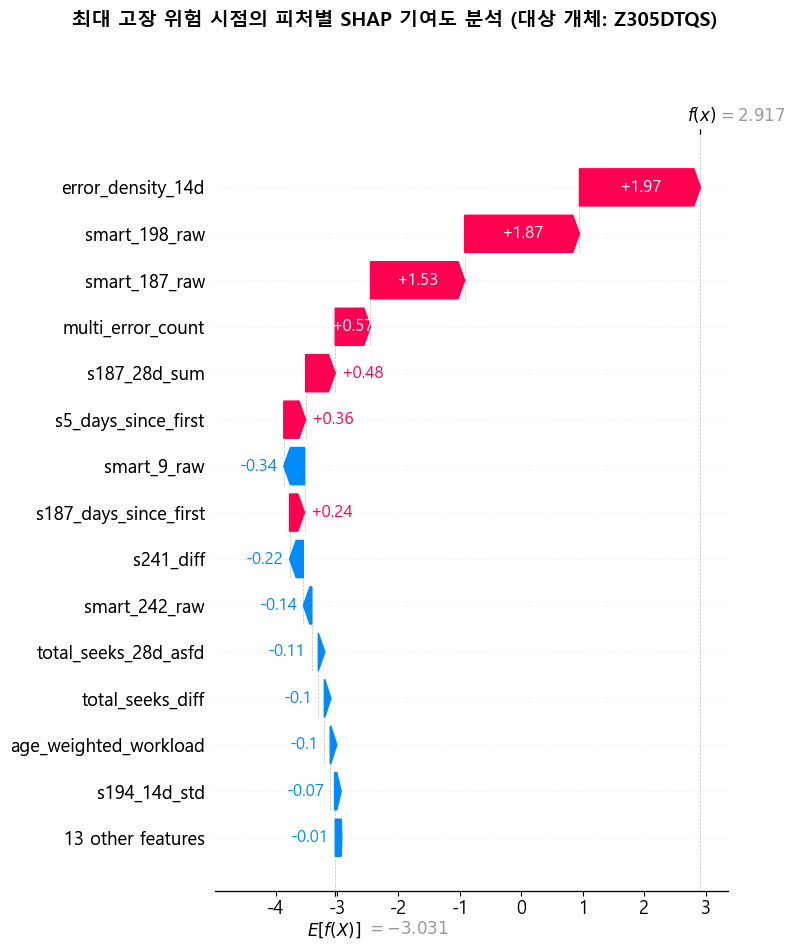


[§9.2] Waterfall Plot — 개체: Z3015L9W
       최고 위험 시점: 2018-06-16 (예측 확률=0.9634)


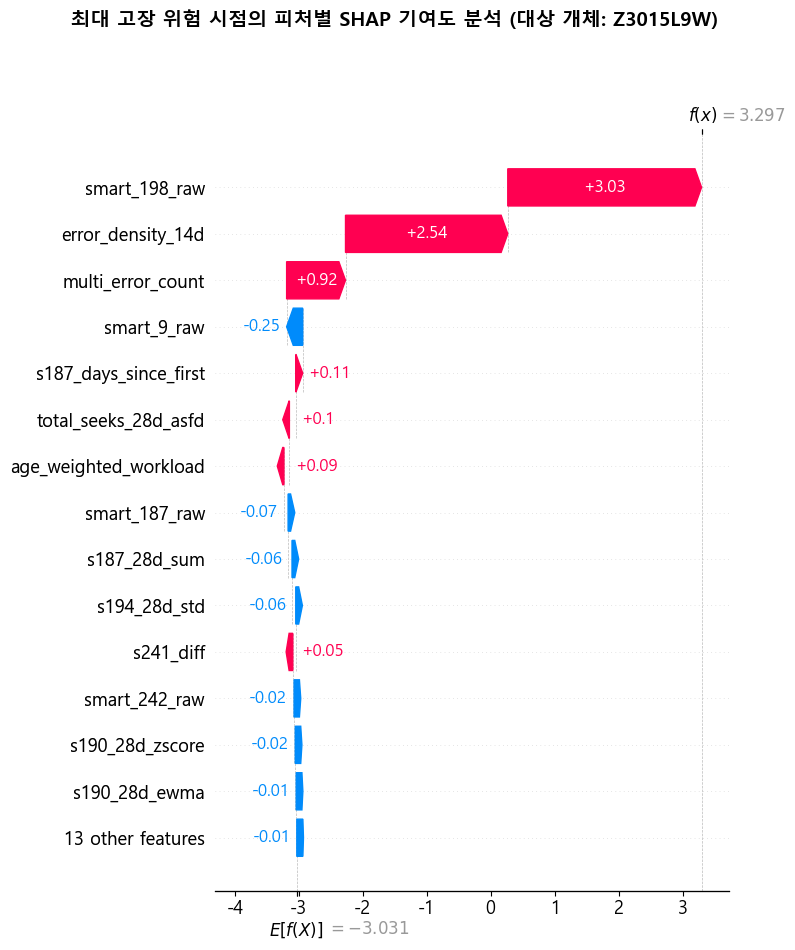

In [ ]:
# §9.2 Waterfall Plot — 고장 확률이 가장 높은 시점 (각 개체별)
for serial in target_serials:
    df_entity = df_test[df_test['base_serial'] == serial].sort_values(cfg.DATE_COL)
    X_entity = df_entity[FEATURE_COLS].reset_index(drop=True)

    # 앙상블 전체의 SHAP 평균 계산
    sv_entity_list = []
    for model in models:
        exp = shap.TreeExplainer(model)
        sv_e = exp.shap_values(X_entity)
        if isinstance(sv_e, list):
            sv_e = sv_e[1]
        sv_entity_list.append(sv_e)
    mean_sv_entity = np.mean(sv_entity_list, axis=0)

    # 고장 확률이 가장 높은 시점 선택
    peak_idx = df_entity["_prob"].values.argmax()
    peak_date = df_entity[cfg.DATE_COL].iloc[peak_idx].date()
    peak_prob = df_entity["_prob"].iloc[peak_idx]
    
    print(f"\n" + "="*70)
    print(f"[§9.2] Waterfall Plot — 개체: {serial}")
    print(f"       최고 위험 시점: {peak_date} (예측 확률={peak_prob:.4f})")
    print("="*70)

    # 첫 번째 모델 기준 expected_value 사용
    base_vals = np.mean([shap.TreeExplainer(m).expected_value for m in models])
    if isinstance(base_vals, np.ndarray):
        base_vals = base_vals[1]

    # data=None으로 설정하여 좌측의 연한 회색 원본 피처값을 숨김 (보다 세련된 뷰)
    explanation = shap.Explanation(
        values=mean_sv_entity[peak_idx],
        base_values=float(base_vals),
        feature_names=FEATURE_COLS,
    )

    shap.plots.waterfall(explanation, max_display=15, show=False)
    
    # SHAP 라이브러리 내부에서 사용하는 유니코드 마이너스 기호(\u2212) 폰트 깨짐 해결
    fig = plt.gcf()
    for ax in fig.axes:
        for t in ax.texts:
            t.set_text(t.get_text().replace('\u2212', '-'))
        labels = [l.get_text().replace('\u2212', '-') for l in ax.get_xticklabels()]
        ax.set_xticklabels(labels)
        labels = [l.get_text().replace('\u2212', '-') for l in ax.get_yticklabels()]
        ax.set_yticklabels(labels)
        
    fig.suptitle(f"최대 고장 위험 시점의 피처별 SHAP 기여도 분석 (대상 개체: {serial})", fontsize=14, fontweight="bold", y=1.05)
    plt.tight_layout()
    plt.show()


---
## §9.3 시간 기반 해석 (Temporal Interpretation)

고장은 하루아침에 발생하지 않고 점진적으로 열화됩니다.  
고장 전 **`TEMPORAL_WINDOW_DAYS`일** 동안 각 피처의 SHAP 기여도가 어떻게 변화했는지 추적합니다.

- **x축:** 고장 직전 경과일 (D-N → D-1 방향으로 진행)
- **y축:** 해당 피처의 SHAP 값 (양수 = 고장 확률 증가 기여)



[§9.3] 시간 기반 SHAP Trajectory — 개체: S301KX66
       분석 기간: 2020-06-08 ~ 2020-07-07 (30일)


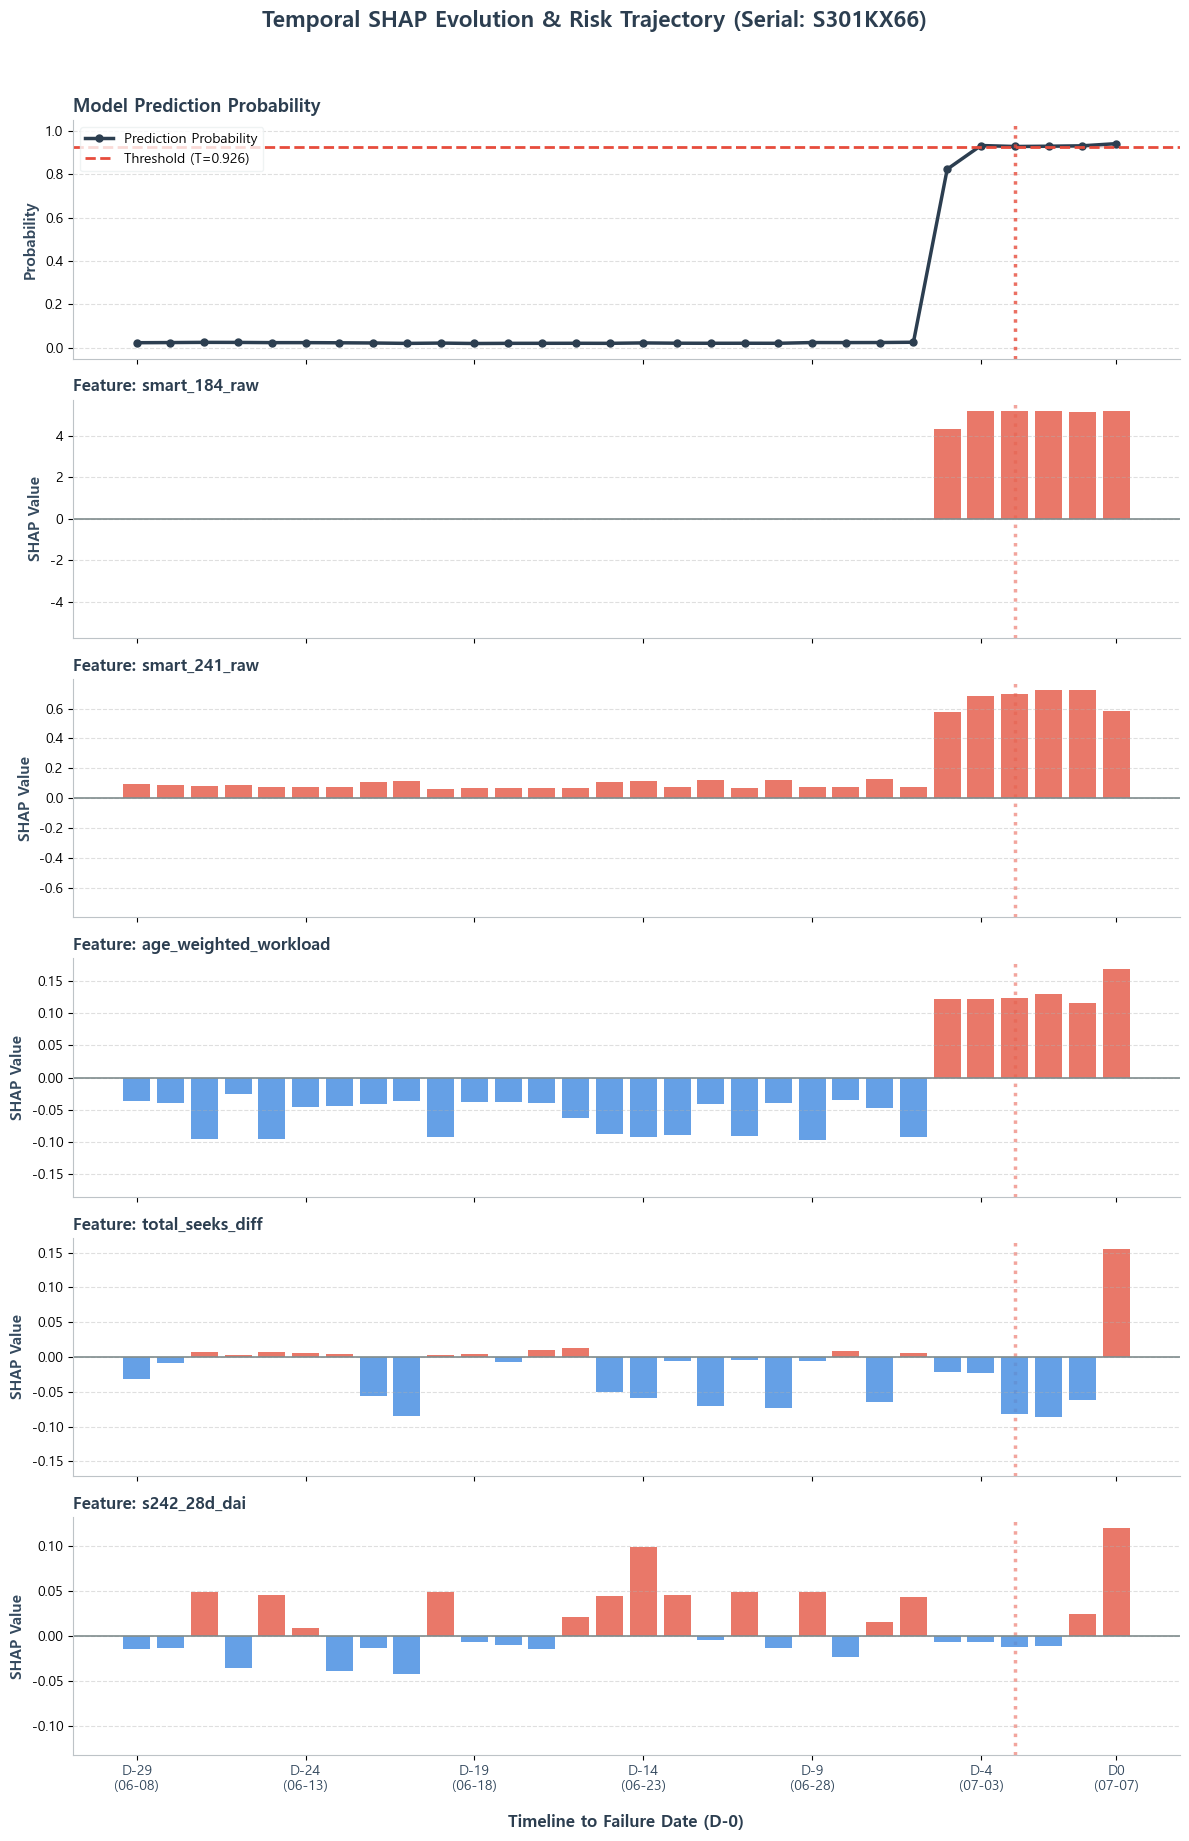


개체 S301KX66 분석 완료. 상위 5개 피처: ['smart_184_raw', 'smart_241_raw', 'age_weighted_workload', 'total_seeks_diff', 's242_28d_dai']


[§9.3] 시간 기반 SHAP Trajectory — 개체: Z305DTQS
       분석 기간: 2021-02-16 ~ 2021-03-17 (30일)


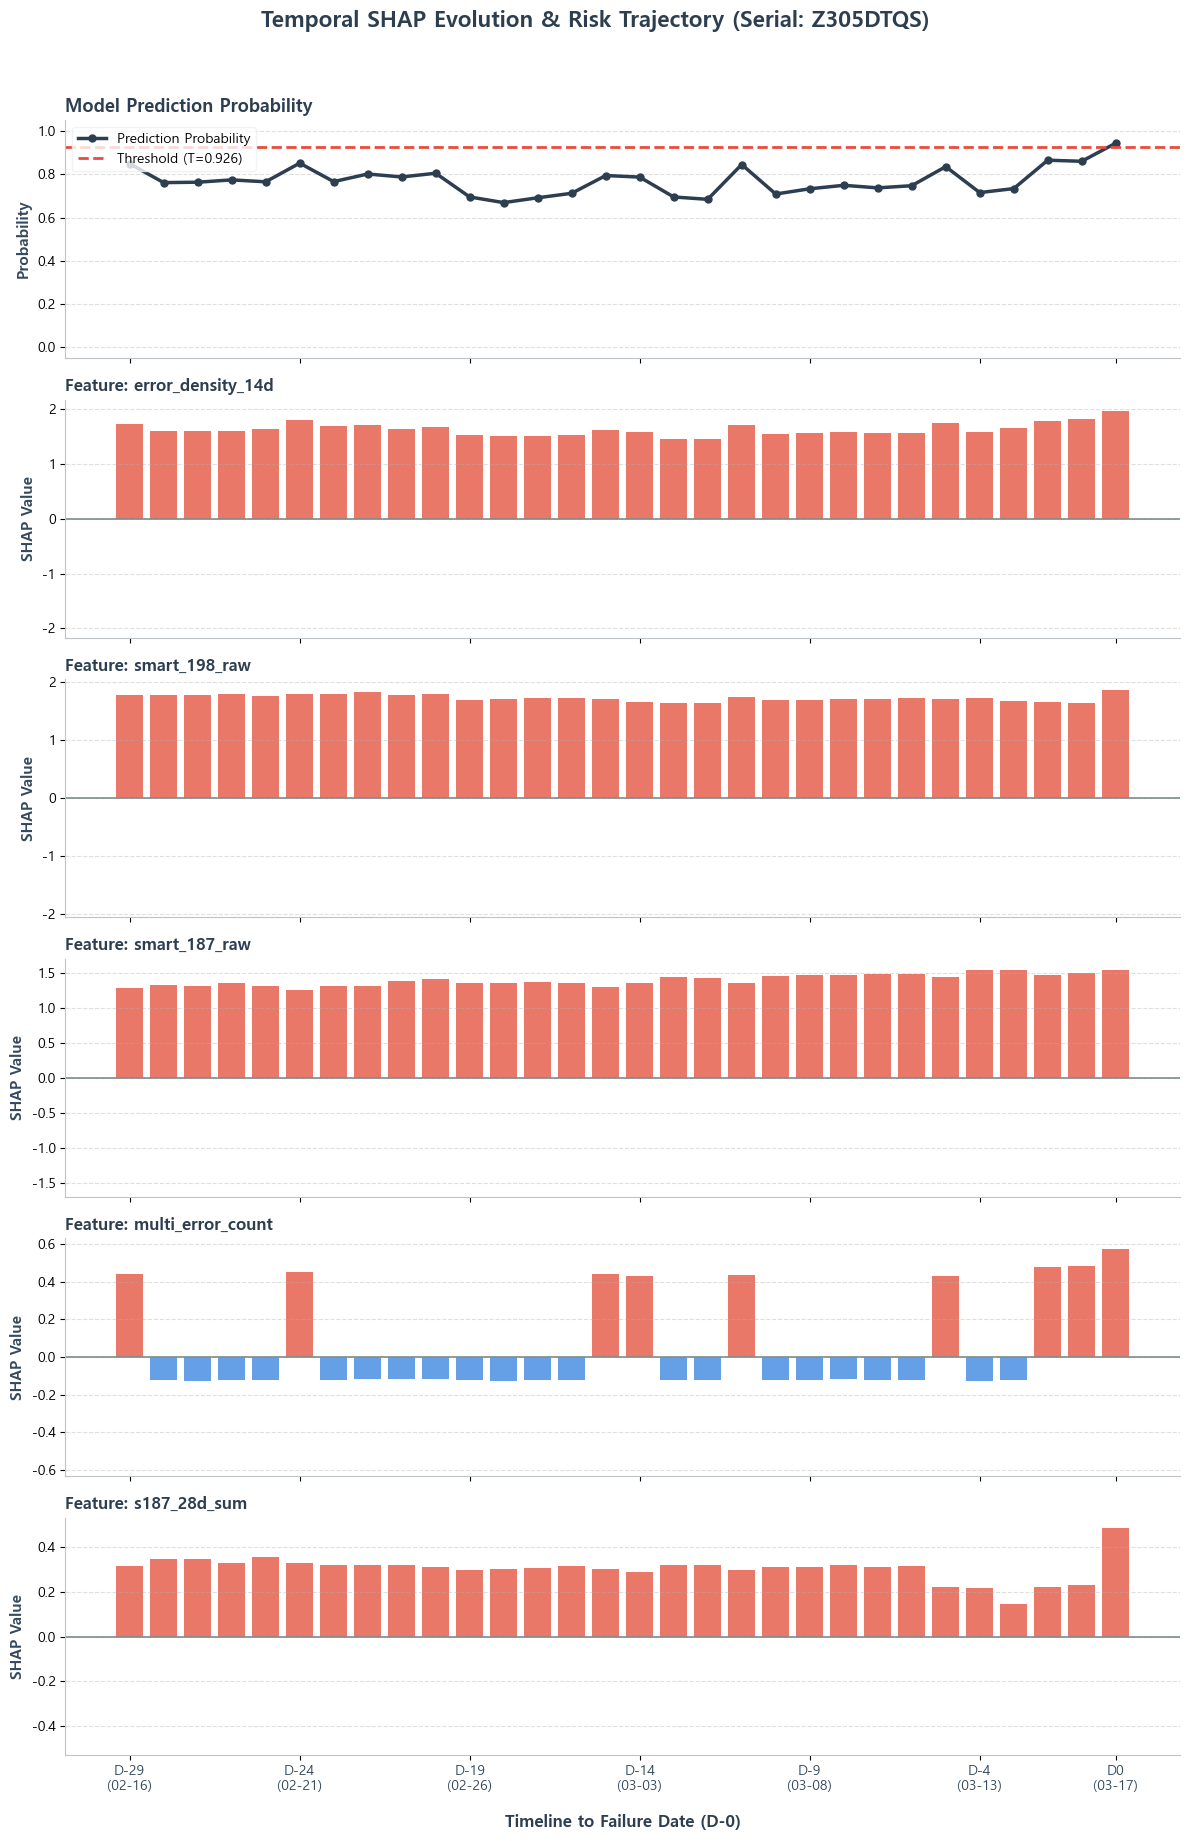


개체 Z305DTQS 분석 완료. 상위 5개 피처: ['error_density_14d', 'smart_198_raw', 'smart_187_raw', 'multi_error_count', 's187_28d_sum']


[§9.3] 시간 기반 SHAP Trajectory — 개체: Z3015L9W
       분석 기간: 2018-05-19 ~ 2018-06-17 (30일)


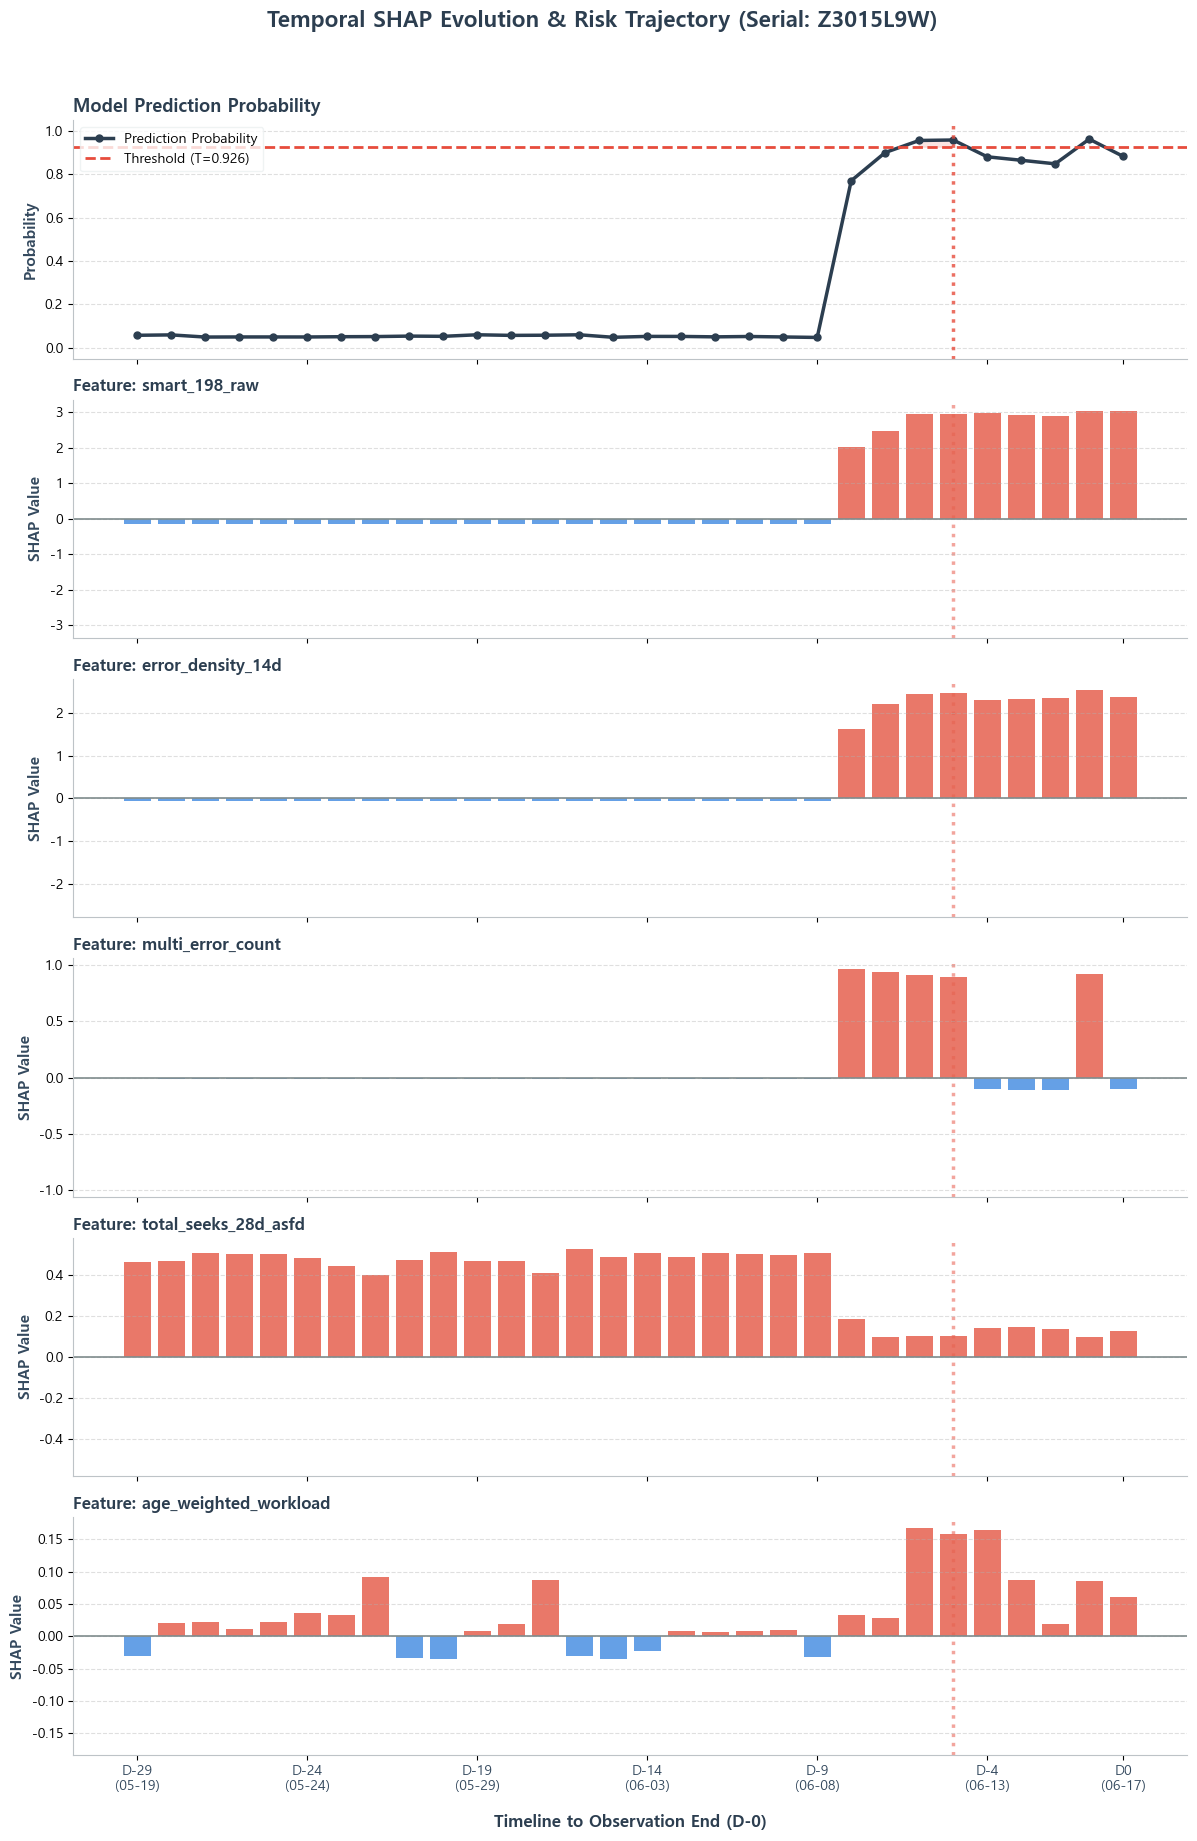


개체 Z3015L9W 분석 완료. 상위 5개 피처: ['smart_198_raw', 'error_density_14d', 'multi_error_count', 'total_seeks_28d_asfd', 'age_weighted_workload']


In [13]:
# §9.3 — 고장 전 N일 창 SHAP Trajectory (각 개체별)
window_days = cfg.TEMPORAL_WINDOW_DAYS
top_n = cfg.TEMPORAL_TOP_N_FEATS

for serial in target_serials:
    df_entity = df_test[df_test['base_serial'] == serial].sort_values(cfg.DATE_COL)
    info = df_best_disk[df_best_disk['base_serial'] == serial].iloc[0]
    
    is_failed = info['is_failed']
    is_alarmed = info['is_alarmed']
    
    # 알람 발령일 계산 (세로선 표시용)
    alarms = (df_entity['_prob'] >= BEST_T).astype(int)
    rolling = alarms.rolling(window=ALARM_WINDOW, min_periods=1).sum()
    idx = np.where(rolling >= BEST_N)[0]
    first_alarm_date = df_entity[cfg.DATE_COL].iloc[idx[0]] if len(idx) > 0 else None
    
    if is_failed == 1:
        ref_date = df_entity[cfg.DATE_COL].max()
        title_suffix = "Failure Date (D-0)"
    else:
        if is_alarmed == 1:
            if first_alarm_date is not None:
                ref_date = min(first_alarm_date + pd.Timedelta(days=5), df_entity[cfg.DATE_COL].max())
            else:
                ref_date = df_entity[cfg.DATE_COL].max()
            title_suffix = "Observation End (D-0)"
        else:
            ref_date = df_entity[cfg.DATE_COL].max()
            title_suffix = "Observation End (D-0)"

    start_date = ref_date - pd.Timedelta(days=window_days - 1)
    df_window = df_entity[(df_entity[cfg.DATE_COL] >= start_date) & (df_entity[cfg.DATE_COL] <= ref_date)].copy().reset_index(drop=True)
    
    print(f"\n\n" + "="*70)
    print(f"[§9.3] 시간 기반 SHAP Trajectory — 개체: {serial}")
    print(f"       분석 기간: {start_date.date()} ~ {ref_date.date()} ({len(df_window)}일)")
    print("="*70)

    if len(df_window) == 0:
        print("⚠️  분석 기간 내 데이터가 없습니다. TEMPORAL_WINDOW_DAYS를 늘려보세요.")
        continue

    X_window = df_window[FEATURE_COLS].reset_index(drop=True)

    # 윈도우 구간 SHAP 계산
    sv_window_list = []
    for model in models:
        exp = shap.TreeExplainer(model)
        sv_w = exp.shap_values(X_window)
        if isinstance(sv_w, list):
            sv_w = sv_w[1]
        sv_window_list.append(sv_w)
    mean_sv_window = np.mean(sv_window_list, axis=0)

    # 양수 방향(위험 증가) 최대값을 기준으로 정렬
    max_pos_window = np.max(mean_sv_window, axis=0) 
    top_feat_idx = np.argsort(max_pos_window)[::-1][:top_n]
    top_feat_names = [FEATURE_COLS[idx] for idx in top_feat_idx]

    dates = df_window[cfg.DATE_COL].dt.date.values
    days_from_last = [- (ref_date.date() - d).days for d in dates]

    # 시각화 (종합 확률 + 상위 피처 SHAP)
    # 폰트 및 스타일 고급화
    fig, axes = plt.subplots(top_n + 1, 1, figsize=(12, 3 * (top_n + 1)), sharex=True)
    fig.patch.set_facecolor('#ffffff')
    
    # 1. 최상단: 전체 모델 예측 확률 궤적 및 임계값
    ax_prob = axes[0]
    probs = df_window["_prob"].values
    
    ax_prob.plot(days_from_last, probs, marker='o', color='#2c3e50', lw=2.5, markersize=5, label="Prediction Probability")
    ax_prob.axhline(BEST_T, color='#e74c3c', linestyle='--', lw=2, label=f"Threshold (T={BEST_T:.3f})")
    ax_prob.fill_between(days_from_last, probs, BEST_T, where=(probs >= BEST_T), color='#e74c3c', alpha=0.15)
    
    # 고장 예측일 세로선 표시 (확률 그래프)
    if first_alarm_date is not None:
        alarm_day = - (ref_date.date() - first_alarm_date.date()).days
        if -window_days <= alarm_day <= 0:
            ax_prob.axvline(alarm_day, color='#e74c3c', linestyle=':', lw=2.5, alpha=0.8)

    ax_prob.set_ylabel("Probability", fontsize=11, fontweight="bold", color='#34495e')
    ax_prob.set_title("Model Prediction Probability", fontsize=13, fontweight="bold", loc='left', color='#2c3e50')
    ax_prob.set_ylim(-0.05, 1.05)
    
    # 깔끔한 범례
    ax_prob.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#ecf0f1')
    ax_prob.grid(axis='y', linestyle='--', alpha=0.4)
    ax_prob.spines['top'].set_visible(False)
    ax_prob.spines['right'].set_visible(False)
    ax_prob.spines['left'].set_color('#bdc3c7')
    ax_prob.spines['bottom'].set_color('#bdc3c7')

    # 2. 하단: 상위 피처별 SHAP 기여도
    # 세련된 컬러 팔레트 (위험=coral, 안전=cornflowerblue)
    pos_color = '#e6614f'
    neg_color = '#4a90e2'
    
    for ax, feat_name, feat_idx in zip(axes[1:], top_feat_names, top_feat_idx):
        shap_vals = mean_sv_window[:, feat_idx]

        # SHAP 값 (막대 그래프)
        bars = ax.bar(days_from_last, shap_vals, 
                      color=[pos_color if v > 0 else neg_color for v in shap_vals], 
                      alpha=0.85, width=0.8)
        
        ax.axhline(0, color="#7f8c8d", lw=1.2, ls="-")
        
        # 고장 예측일 세로선 표시
        if first_alarm_date is not None:
            alarm_day = - (ref_date.date() - first_alarm_date.date()).days
            if -window_days <= alarm_day <= 0:
                ax.axvline(alarm_day, color='#e74c3c', linestyle=':', lw=2.5, alpha=0.5, zorder=0)

        max_abs = max(abs(shap_vals.min()), abs(shap_vals.max())) * 1.1
        if max_abs > 0:
            ax.set_ylim(-max_abs, max_abs)
            
        ax.set_ylabel("SHAP Value", fontsize=11, fontweight="bold", color='#34495e')
        ax.set_title(f"Feature: {feat_name}", fontsize=12, fontweight="bold", loc='left', color='#2c3e50')
        ax.grid(axis="y", linestyle='--', alpha=0.4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#bdc3c7')
        ax.spines['bottom'].set_color('#bdc3c7')

    # X축 눈금 설정 (날짜 포함)
    tick_locs = np.arange(-window_days + 1, 1, 5)
    if 0 not in tick_locs:
        tick_locs = np.append(tick_locs, 0)
    
    # 틱 라벨 생성 (D-Day 및 실제 날짜 포함)
    xticklabels = []
    for x in tick_locs:
        if x in days_from_last:
            idx = days_from_last.index(x)
            real_date = dates[idx].strftime('%m-%d')
        else:
            real_date = (ref_date + pd.Timedelta(days=int(x))).strftime('%m-%d')
        xticklabels.append(f"D{int(x)}\n({real_date})")

    axes[-1].set_xticks(tick_locs)
    axes[-1].set_xticklabels(xticklabels, fontsize=10, color='#34495e')
    axes[-1].set_xlabel(f"Timeline to {title_suffix}", fontsize=12, fontweight="bold", color='#2c3e50', labelpad=15)

    fig.suptitle(
        f"Temporal SHAP Evolution & Risk Trajectory (Serial: {serial})",
        fontsize=16, fontweight="bold", color='#2c3e50', y=1.02
    )
    plt.tight_layout()
    plt.show()
    print(f"\n개체 {serial} 분석 완료. 상위 {top_n}개 피처: {top_feat_names}")


---
## §9.4 실무 활용 요약

본 해석 분석을 통해 도출할 수 있는 실무적 의미를 정리합니다.

In [ ]:
# §9.4 — 실무 활용 요약 출력
SEP = "=" * 65

print(SEP)
print("  §9.4  실무 활용 효과 요약")
print(SEP)

# 상위 피처 목록 (§9.1 결과 기반)
top5_global = shap_rank_df["feature"].head(5).tolist()
print("\n▶ [전역 해석 - §9.1] 주요 고장 기여 피처 Top 5:")
for rank, feat in enumerate(top5_global, 1):
    score = shap_rank_df.loc[shap_rank_df["feature"] == feat, "mean_abs_shap"].values[0]
    print(f"    {rank}. {feat:<35} (Mean |SHAP| = {score:.5f})")

print(f"\n▶ [국소 해석 - §9.2] 분석 개체: {', '.join(target_serials)}")
print(f"    → Waterfall Plot에서 해당 시점의 개별 피처 기여도 확인 가능")

print(f"\n▶ [시간 해석 - §9.3] 고장/오탐 전 {window_days}일 창 분석")
print(f"    → 어느 피처가 언제부터 급격히 기여도가 상승했는지 궤적 확인 가능")

print(f"\n▶ 실무 의미:")
print(f"    1. 조기 경보 원인 설명: 특정 SMART 지표가 언제부터 이상 신호를 보냈는지 설명")
print(f"    2. 유지보수 판단 근거: 엔지니어에게 '이 디스크는 A 피처 때문에 경보 발령'이라는 근거 제공")
print(f"    3. 모델 신뢰성 향상: Black-box 모델의 의사결정 과정을 투명하게 공개")
print(SEP)


  §9.4  실무 활용 효과 요약

▶ [전역 해석 - §9.1] 주요 고장 기여 피처 Top 5:
    1. smart_198_raw                       (Mean |SHAP| = 0.61760)
    2. smart_187_raw                       (Mean |SHAP| = 0.38754)
    3. error_density_14d                   (Mean |SHAP| = 0.36514)
    4. total_seeks_28d_asfd                (Mean |SHAP| = 0.22877)
    5. smart_9_raw                         (Mean |SHAP| = 0.17667)

▶ [국소 해석 - §9.2] 분석 개체: S301KX66, Z305DTQS, Z3015L9W
    → Waterfall Plot에서 해당 시점의 개별 피처 기여도 확인 가능

▶ [시간 해석 - §9.3] 고장/오탐 전 30일 창 분석
    → 어느 피처가 언제부터 급격히 기여도가 상승했는지 궤적 확인 가능

▶ 실무 의미:
    1. 조기 경보 원인 설명: 특정 SMART 지표가 언제부터 이상 신호를 보냈는지 설명
    2. 유지보수 판단 근거: 엔지니어에게 '이 디스크는 A 피처 때문에 경보 발령'이라는 근거 제공
    3. 모델 신뢰성 향상: Black-box 모델의 의사결정 과정을 투명하게 공개
